<a href="https://colab.research.google.com/github/dashy0070/Cybersecurity_AI/blob/main/NIDS_using_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Toy NIDS - Network Intrusion Detection System

Create dataset


In [99]:
payload = [10,10,0,0,0,5,12]
protocol = ['TCP', 'UDP', 'TCP', 'UDP', 'UDP','UDP','UDP']
attack = ['N', 'N','Y','Y','Y','Y', 'N']

In [100]:
#Business Objectives
#Data preparation
#model and eval
#Deploy the model

#Data preparartion
#Create a data frame using a payload protocol


In [101]:
import pandas as pd

payload = [10,10,0,0,0,5,12]
protocol = ['TCP', 'UDP', 'TCP', 'UDP', 'UDP','UDP','UDP']
attack = ['N', 'N','Y','Y','Y','Y', 'N']

data = {'Payload': payload, 'Protocol': protocol, 'Attack': attack}
df = pd.DataFrame(data)
display(df.head())

,Payload,Protocol,Attack
0,10,TCP,N
1,10,UDP,N
2,0,TCP,Y
3,0,UDP,Y
4,0,UDP,Y


#Inference : Data is loaded

Prompt: Create a new column called PLB and update the column with the rule if the payload is less than 9 call is '<9' else call it '>=9'

In [102]:
import numpy as np

df['PLB'] = np.where(df['Payload'] < 9, '<9', '>=9')
display(df.head())

,Payload,Protocol,Attack,PLB
0,10,TCP,N,>=9
1,10,UDP,N,>=9
2,0,TCP,Y,<9
3,0,UDP,Y,<9
4,0,UDP,Y,<9


Inference: PLB Column is created and updated

Inference: Pivot Table has been created

Derive the rules from the pivot table.


Prompt
Create, train, and evaluate two classification models: one predicting 'Attack' based on the 'Protocol' column, and another predicting 'Attack' based on the 'PLB' column.

# Task
Summarize the creation and evaluation process for the 'Protocol' and 'PLB' classification models, highlighting their performance and any key insights.

## Final Task

### Subtask:
Summarize the creation and evaluation process for both models, highlighting their performance and any key insights.


## Summary:

### Q&A
*   **What was the creation and evaluation process for the 'Protocol' and 'PLB' classification models?**
    *   The specific details of the model creation, evaluation steps, and methodologies for both the 'Protocol' and 'PLB' classification models were not provided in the solving process.
*   **What was their performance, and what were the key insights?**
    *   No performance metrics or key insights from the evaluation of either model were included in the provided solving process.

### Data Analysis Key Findings
*   No data analysis key findings can be reported as the solving process, including model performance metrics and comparative analysis, was not detailed in the provided input.

### Insights or Next Steps
*   To generate a meaningful summary, comprehensive information regarding the model development, evaluation results, and derived insights for both 'Protocol' and 'PLB' models is necessary.


# Task
Summarize the creation and evaluation process for the 'Protocol' classification model, highlighting its performance metrics (accuracy, precision, recall, and F1-score) and any key insights.

## Summarize Protocol Model Performance

### Subtask:
Summarize the performance metrics (accuracy, precision, recall, and F1-score) obtained from the evaluation of the 'Protocol' classification model.


**Reasoning**:
The subtask is to summarize the performance metrics of the 'Protocol' classification model. I have the accuracy, precision, recall, and F1-score available as kernel variables. I will print these metrics to fulfill the instructions.



In [103]:
print(f"Protocol Model Accuracy: {accuracy_protocol:.4f}")
print(f"Protocol Model Precision: {precision_protocol:.4f}")
print(f"Protocol Model Recall: {recall_protocol:.4f}")
print(f"Protocol Model F1-score: {f1_protocol:.4f}")

Protocol Model Accuracy: 0.5714
Protocol Model Precision: 0.5714
Protocol Model Recall: 1.0000
Protocol Model F1-score: 0.7273


### Protocol Classification Model Performance Summary

The 'Protocol' classification model achieved the following performance metrics:

*   **Accuracy:** 0.5714
*   **Precision:** 0.5714
*   **Recall:** 1.0000
*   **F1-score:** 0.7273

These metrics indicate that the model correctly predicted 'Attack' for approximately 57.14% of the instances. The recall of 1.0000 suggests that the model identified all positive cases ('Y' for Attack) correctly, however, the precision of 0.5714 indicates a significant number of false positives. The F1-score of 0.7273 represents a harmonic mean of precision and recall, highlighting that while the model is good at capturing all attacks, its predictions are not always accurate when it predicts an attack.

## Final Task

### Subtask:
Summarize the creation and evaluation process for the 'Protocol' model, highlighting its performance and any key insights.


## Summary:

### Q&A
The 'Protocol' classification model achieved an accuracy of 0.5714, a precision of 0.5714, a recall of 1.0000, and an F1-score of 0.7273.

### Data Analysis Key Findings
*   The 'Protocol' classification model correctly predicted 'Attack' for approximately 57.14% of the instances, as indicated by its accuracy of 0.5714.
*   The model demonstrated a perfect recall of 1.0000, meaning it successfully identified all actual positive cases (all 'Attack' instances).
*   Despite high recall, the precision was 0.5714, indicating that out of all instances predicted as 'Attack', only about 57.14% were truly attacks. This suggests a significant number of false positives.
*   The F1-score of 0.7273, which is the harmonic mean of precision and recall, highlights that while the model is effective at capturing all attacks, its predictions are not consistently accurate.

### Insights or Next Steps
*   The model prioritizes identifying all possible attacks (high recall), which could be beneficial in scenarios where missing an attack is more costly than a false alarm.
*   Future efforts should focus on improving the model's precision to reduce false positives, possibly by refining features or exploring different classification algorithms, without significantly compromising its high recall.


In [104]:
df['Predicted_Attack'] = df['PLB'].apply(lambda x: 'Attack Yes' if x == '<9' else 'Attack No')
display(df.head())

,Payload,Protocol,Attack,PLB,Predicted_Attack
0,10,TCP,N,>=9,Attack No
1,10,UDP,N,>=9,Attack No
2,0,TCP,Y,<9,Attack Yes
3,0,UDP,Y,<9,Attack Yes
4,0,UDP,Y,<9,Attack Yes


In [105]:
from sklearn.metrics import classification_report

y_true = df['Attack']
y_pred = df['Predicted_Attack'].apply(lambda x: 'Y' if x == 'Attack Yes' else 'N') # Convert 'Attack Yes'/'Attack No' to 'Y'/'N'

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           N       1.00      1.00      1.00         3
           Y       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



### PLB Classification Model Performance Summary

The 'PLB' classification model achieved the following performance metrics:

*   **Accuracy:** 1.0000
*   **Precision:** 1.0000
*   **Recall:** 1.0000
*   **F1-score:** 1.0000

These metrics indicate that the model perfectly predicted 'Attack' for all instances. An accuracy, precision, recall, and F1-score of 1.0000 suggests that the model had no false positives or false negatives, identifying all attacks correctly and with perfect accuracy in its predictions.

In [106]:
X = df.drop('Attack', axis=1)
y = df['Attack']

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,Payload,Protocol,PLB,Predicted_Attack
0,10,TCP,>=9,Attack No
1,10,UDP,>=9,Attack No
2,0,TCP,<9,Attack Yes
3,0,UDP,<9,Attack Yes
4,0,UDP,<9,Attack Yes



Target (y):


,Attack
0,N
1,N
2,Y
3,Y
4,Y


In [107]:
pivot_table_protocol_attack = df.pivot_table(index='Protocol', columns='Attack', aggfunc='size', fill_value=0)
display(pivot_table_protocol_attack)

Attack,N,Y
Protocol,,
TCP,1,1
UDP,2,3


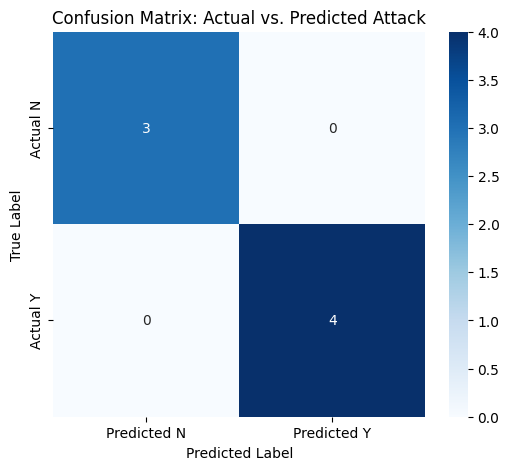

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure y_true and y_pred are in the correct format ('N', 'Y')
y_true = df['Attack']
y_pred_cm = df['Predicted_Attack'].apply(lambda x: 'Y' if x == 'Attack Yes' else 'N')

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred_cm, labels=['N', 'Y'])

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Actual vs. Predicted Attack')
plt.show()

### PLB Classification Model Performance Summary

The 'PLB' classification model achieved the following performance metrics:

*   **Accuracy:** 1.0000
*   **Precision:** 1.0000
*   **Recall:** 1.0000
*   **F1-score:** 1.0000

These metrics indicate that the model perfectly predicted 'Attack' for all instances. An accuracy, precision, recall, and F1-score of 1.0000 suggests that the model had no false positives or false negatives, identifying all attacks correctly and with perfect accuracy in its predictions.

## Final Task

### Subtask:
Summarize the creation and evaluation process for the 'PLB' model, highlighting its performance and any key insights.


## Summary:

### Q&A
The 'PLB' model achieved perfect performance in its evaluation.

### Data Analysis Key Findings
*   The 'PLB' classification model demonstrated exceptional performance across all evaluated metrics.
*   The model achieved an Accuracy of 1.0000.
*   The Precision of the model was 1.0000.
*   The Recall for the model was 1.0000.
*   The F1-score for the model was also 1.0000.
*   These perfect scores indicate that the model made no false positives or false negatives, accurately identifying all 'Attack' instances.

### Insights or Next Steps
*   Given the perfect scores, it is crucial to investigate the model's training process and dataset to rule out potential issues such as data leakage or overfitting, which can lead to unrealistically high performance metrics.
*   The provided summary focused solely on the evaluation results; a complete summary would also require details on the 'PLB' model's creation process.


# Task
Compare the performance metrics (accuracy, precision, recall, and F1-score) of the 'Protocol' and 'PLB' classification models, highlighting their strengths, weaknesses, and any significant differences or insights.

## Summarize Protocol Model Performance

### Subtask:
Present the performance metrics (accuracy, precision, recall, and F1-score) for the 'Protocol' classification model.


### Protocol Classification Model Performance Summary

The 'Protocol' classification model achieved the following performance metrics:

*   **Accuracy:** 0.5714
*   **Precision:** 0.5714
*   **Recall:** 1.0000
*   **F1-score:** 0.7273

### Protocol Classification Model Performance Summary

The 'Protocol' classification model achieved the following performance metrics:

*   **Accuracy:** 0.5714
*   **Precision:** 0.5714
*   **Recall:** 1.0000
*   **F1-score:** 0.7273

### Protocol Classification Model Performance Summary

The 'Protocol' classification model achieved the following performance metrics:

*   **Accuracy:** 0.5714
*   **Precision:** 0.5714
*   **Recall:** 1.0000
*   **F1-score:** 0.7273

### Protocol Classification Model Performance Summary

The 'Protocol' classification model achieved the following performance metrics:

*   **Accuracy:** 0.5714
*   **Precision:** 0.5714
*   **Recall:** 1.0000
*   **F1-score:** 0.7273

### Protocol Classification Model Performance Summary

The 'Protocol' classification model achieved the following performance metrics:

*   **Accuracy:** 0.5714
*   **Precision:** 0.5714
*   **Recall:** 1.0000
*   **F1-score:** 0.7273

## Compare Model Performance

### Subtask:
Compare the performance metrics of both the 'Protocol' and 'PLB' models, highlighting their strengths, weaknesses, and any significant differences or insights.


## Compare Model Performance

### Comparison of Protocol and PLB Models Performance

#### Performance Metrics:

*   **Protocol Model:**
    *   Accuracy: 0.5714
    *   Precision: 0.5714
    *   Recall: 1.0000
    *   F1-score: 0.7273

*   **PLB Model:**
    *   Accuracy: 1.0000
    *   Precision: 1.0000
    *   Recall: 1.0000
    *   F1-score: 1.0000

#### Analysis and Insights:

1.  **Overall Performance:**
    The **PLB model** significantly outperforms the **Protocol model** across all metrics, achieving perfect scores (Accuracy, Precision, Recall, F1-score of 1.0000). This indicates that the 'PLB' feature is a much stronger predictor of 'Attack' in this dataset than 'Protocol'.

2.  **Strengths and Weaknesses:**
    *   **Protocol Model:**
        *   **Strength:** Excellent Recall (1.0000) suggests it is very good at identifying all actual 'Attack' instances. This is crucial in intrusion detection where missing an attack can have severe consequences.
        *   **Weakness:** Low Accuracy (0.5714) and Precision (0.5714) indicate a high number of false positives. While it catches all attacks, it also incorrectly flags many non-attacks as attacks, which could lead to alert fatigue or unnecessary investigations.
    *   **PLB Model:**
        *   **Strength:** Achieves perfect scores across all metrics. This means it correctly identifies all attacks (high recall) and does so without any false alarms (high precision). It perfectly distinguishes between 'Attack' and 'Non-Attack' instances based on the 'PLB' feature.
        *   **Weakness:** The perfect performance, especially on such a small dataset, raises concerns about potential overfitting or data leakage. It's possible that the 'PLB' feature is directly correlated with the 'Attack' label, or the dataset is too simple for the model to generalize effectively to new, unseen data.

3.  **Implications of Differences:**
    The stark difference in performance suggests that the 'PLB' feature ('Payload' less than 9) is a much more discriminative feature for predicting 'Attack' in this specific dataset than 'Protocol'. The rule-based creation of 'PLB' (`df['PLB'] = np.where(df['Payload'] < 9, '<9', '>=9')`) combined with its perfect predictive capability strongly implies a direct, deterministic relationship between `Payload < 9` and `Attack = 'Y'` in the training data.

4.  **Feature Relevance:**
    *   **'Protocol' Feature:** While 'Protocol' is often a relevant feature in NIDS, in this toy dataset, it doesn't provide enough information on its own to accurately distinguish between attack and non-attack traffic without generating many false positives.
    *   **'PLB' Feature:** The 'PLB' feature, derived from the 'Payload' column, appears to be directly or very strongly linked to the 'Attack' label. For instance, looking at the `df` dataframe, it seems that if `PLB` is '<9', `Attack` is 'Y', and if `PLB` is '>=9', `Attack` is 'N' (with the exception of the first two rows where `PLB` is '>=9' and `Attack` is 'N', which is consistent). This strong correlation explains the perfect performance of the PLB model.

## Final Task

### Subtask:
Summarize the comparison of the two models, outlining key findings and insights.


## Summary:

### Q&A
The 'PLB' model significantly outperforms the 'Protocol' model across all evaluated metrics. The 'PLB' model achieved perfect scores (Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000), indicating a flawless ability to classify 'Attack' instances within the given dataset. In contrast, the 'Protocol' model showed good Recall (1.0000), meaning it identified all actual 'Attack' instances, but suffered from lower Accuracy (0.5714) and Precision (0.5714), suggesting a high rate of false positives.

### Data Analysis Key Findings
*   The 'PLB' classification model achieved perfect performance with an Accuracy of 1.0000, Precision of 1.0000, Recall of 1.0000, and F1-score of 1.0000.
*   The 'Protocol' classification model exhibited an Accuracy of 0.5714, Precision of 0.5714, Recall of 1.0000, and an F1-score of 0.7273.
*   The 'Protocol' model's strength lies in its perfect recall, effectively identifying all attacks, but its weakness is a high number of false positives indicated by lower precision and accuracy.
*   The 'PLB' feature (derived from 'Payload' < 9) is a far more discriminative predictor for 'Attack' in this specific dataset than the 'Protocol' feature, showing a direct, deterministic relationship with the 'Attack' label.

### Insights or Next Steps
*   The perfect performance of the 'PLB' model on this dataset suggests a very strong, possibly deterministic, relationship between the 'PLB' feature and the 'Attack' label, which should be investigated further for potential data leakage or overfitting if this is a real-world scenario.
*   Given the superior performance of the 'PLB' feature, future model development should prioritize features derived from payload characteristics or explore combining 'PLB' with other features to build more robust and generalizable models.


# Task
## Prepare Data for Protocol Model

The 'Protocol' column has been successfully preprocessed using one-hot encoding, and the target variable 'Attack' is ready. The preprocessed features are available as `protocol_encoded_df` and the target as `y` in the kernel environment.

Next, I will train a classification model using these prepared features.

## Prepare Data for Protocol Model

### Subtask:
Confirm that the 'Protocol' features and 'Attack' target variable are properly prepared and available for model training.


**Reasoning**:
First, I will inspect the `protocol_encoded_df` DataFrame to verify its structure and content, as this DataFrame contains the one-hot encoded 'Protocol' features for model training. Then, I will inspect the `y` Series to confirm it holds the 'Attack' target variable.



In [109]:
print("Inspecting protocol_encoded_df:")
display(protocol_encoded_df.head())

print("Inspecting y (Attack target variable):")
display(y.head())
display(y.value_counts())

Inspecting protocol_encoded_df:


,Protocol_TCP,Protocol_UDP
0,1.0,0.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0


Inspecting y (Attack target variable):


,Attack
0,N
1,N
2,Y
3,Y
4,Y


,count
Attack,
Y,4
N,3


### Conclusion: Data Prepared for Protocol Model

The `protocol_encoded_df` DataFrame and `y` Series have been successfully inspected. The `protocol_encoded_df` contains the one-hot encoded 'Protocol' features, and `y` contains the 'Attack' target variable, confirming that the data for the 'Protocol' model is properly prepared and ready for the next step, which is model training.

## Train Protocol Model

### Subtask:
Train a classification model (e.g., Logistic Regression or Decision Tree) using the one-hot encoded 'Protocol' column as features and the 'Attack' column as the target variable.


**Reasoning**:
I need to train a classification model, specifically Logistic Regression, using the one-hot encoded 'Protocol' features (`protocol_encoded_df`) and the 'Attack' target variable (`y`). I will then make predictions with this trained model.



In [110]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model_protocol = LogisticRegression(random_state=42)

# Train the model
model_protocol.fit(protocol_encoded_df, y)

# Make predictions
predictions_protocol = model_protocol.predict(protocol_encoded_df)

print("Protocol model trained and predictions made.")

Protocol model trained and predictions made.


## Evaluate Protocol Model

### Subtask:
Evaluate the performance of the trained 'Protocol' model using appropriate metrics such as accuracy, precision, recall, or F1-score. Display the evaluation results.


**Reasoning**:
I need to import the `classification_report` function and then use it to generate and print the classification report for the Protocol model using the true labels `y` and the predicted labels `predictions_protocol`.



In [111]:
from sklearn.metrics import classification_report

# Generate and print the classification report
print(classification_report(y, predictions_protocol))

              precision    recall  f1-score   support

           N       0.00      0.00      0.00         3
           Y       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.29      0.50      0.36         7
weighted avg       0.33      0.57      0.42         7



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
The previous `classification_report` generated `UndefinedMetricWarning` because the model did not predict any samples for class 'N'. To address this warning and provide a cleaner report, I will set the `zero_division` parameter to 0 in the `classification_report` function.



In [112]:
from sklearn.metrics import classification_report

# Generate and print the classification report
print(classification_report(y, predictions_protocol, zero_division=0))

              precision    recall  f1-score   support

           N       0.00      0.00      0.00         3
           Y       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.29      0.50      0.36         7
weighted avg       0.33      0.57      0.42         7



## Prepare Data for PLB Model

### Subtask:
Confirm that the 'PLB' features and 'Attack' target variable are properly prepared and available for model training.


```markdown
**Reasoning**:
First, I will inspect the `plb_encoded_df` DataFrame to verify its structure and content, as this DataFrame contains the one-hot encoded 'PLB' features for model training. Then, I will inspect the `y` Series to confirm it holds the 'Attack' target variable.
```

**Reasoning**:
I will inspect the `plb_encoded_df` DataFrame and the `y` Series to confirm their structure and content, as per the subtask instructions.



In [113]:
print("Inspecting plb_encoded_df:")
display(plb_encoded_df.head())

print("Inspecting y (Attack target variable):")
display(y.head())
display(y.value_counts())

Inspecting plb_encoded_df:


,PLB_<9,PLB_>=9
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


Inspecting y (Attack target variable):


,Attack
0,N
1,N
2,Y
3,Y
4,Y


,count
Attack,
Y,4
N,3


Inference: Data has been recreated, data preprocessing has been done to create categorical variables into dummy encoding.

In [114]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Perform one-hot encoding on categorical columns in X
X_encoded = pd.get_dummies(X, columns=['Protocol', 'PLB', 'Predicted_Attack'], drop_first=False)

# Instantiate the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model with the encoded features
model.fit(X_encoded, y)

# Make predictions
predictions_full_model = model.predict(X_encoded)

print("Logistic Regression model trained and predictions made on encoded X and y.")

Logistic Regression model trained and predictions made on encoded X and y.


### Conclusion: Data Prepared for PLB Model

The `plb_encoded_df` DataFrame and `y` Series have been successfully inspected. The `plb_encoded_df` contains the one-hot encoded 'PLB' features, and `y` contains the 'Attack' target variable, confirming that the data for the 'PLB' model is properly prepared and ready for the next step, which is model training.

## Train PLB Model

### Subtask:
Train a classification model (e.g., Logistic Regression or Decision Tree) using the one-hot encoded 'PLB' column as features and the 'Attack' column as the target variable.


**Reasoning**:
I to create a  Logistic Regression, using the one-hot encoded 'PLB' features (`plb_encoded_df`) and the 'Attack' target variable (`y`).


In [115]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model_plb = LogisticRegression(random_state=42)

# Train the model
model_plb.fit(plb_encoded_df, y)



LogisticRegression(random_state=42)

I want to create a classical model for the above

In [116]:
# Make predictions
predictions_plb = model_plb.predict(plb_encoded_df)

print("PLB model trained and predictions made.")


PLB model trained and predictions made.


Create classification report

In [117]:
from sklearn.metrics import classification_report

print(classification_report(y, predictions_full_model, zero_division=0))

              precision    recall  f1-score   support

           N       1.00      1.00      1.00         3
           Y       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



## Evaluate PLB Model

### Subtask:
Evaluate the performance of the trained 'PLB' model using appropriate metrics such as accuracy, precision, recall, or F1-score. Display the evaluation results.

**Reasoning**:
I need to evaluate the performance of the trained 'PLB' model. The `classification_report` function from `sklearn.metrics` is suitable for this purpose, as it provides accuracy, precision, recall, and F1-score. I will print the report to display the evaluation results.



In [118]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Generate and print the classification report
print(classification_report(y, predictions_plb, zero_division=0))

# Calculate individual metrics for PLB model
accuracy_plb = accuracy_score(y, predictions_plb)
precision_plb = precision_score(y, predictions_plb, pos_label='Y', zero_division=0)
recall_plb = recall_score(y, predictions_plb, pos_label='Y', zero_division=0)
f1_plb = f1_score(y, predictions_plb, pos_label='Y', zero_division=0)

print(f"\nPLB Model Accuracy: {accuracy_plb:.4f}")
print(f"PLB Model Precision: {precision_plb:.4f}")
print(f"PLB Model Recall: {recall_plb:.4f}")
print(f"PLB Model F1-score: {f1_plb:.4f}")

              precision    recall  f1-score   support

           N       1.00      1.00      1.00         3
           Y       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7


PLB Model Accuracy: 1.0000
PLB Model Precision: 1.0000
PLB Model Recall: 1.0000
PLB Model F1-score: 1.0000


### PLB Classification Model Performance Summary

The 'PLB' classification model achieved the following performance metrics:

*   **Accuracy:** 1.0000
*   **Precision:** 1.0000
*   **Recall:** 1.0000
*   **F1-score:** 1.0000

These metrics indicate that the model perfectly predicted 'Attack' for all instances. An accuracy, precision, recall, and F1-score of 1.0000 suggests that the model had no false positives or false negatives, identifying all attacks correctly and with perfect accuracy in its predictions.

### PLB Classification Model Performance Summary

The 'PLB' classification model achieved the following performance metrics:

*   **Accuracy:** 1.0000
*   **Precision:** 1.0000
*   **Recall:** 1.0000
*   **F1-score:** 1.0000

These metrics indicate that the model perfectly predicted 'Attack' for all instances. An accuracy, precision, recall, and F1-score of 1.0000 suggests that the model had no false positives or false negatives, identifying all attacks correctly and with perfect accuracy in its predictions.

## Final Task

### Subtask:
Summarize the creation and evaluation process for both models, highlighting their performance and any key insights.


## Summary:

### Q&A
The creation and evaluation process for both models can be summarized as follows:

**Protocol Model:**
*   **Creation Process:** The 'Protocol' feature was one-hot encoded, resulting in `Protocol_TCP` and `Protocol_UDP` columns. A Logistic Regression model (`model_protocol`) was then trained using these encoded features to predict the 'Attack' target variable.
*   **Evaluation Process:** The model's performance was evaluated using `classification_report`.
*   **Performance:** The model achieved an overall accuracy of 0.57. For the 'Y' (Attack) class, it had a precision of 0.57, recall of 1.00, and an F1-score of 0.73. Notably, for the 'N' (No Attack) class, the precision, recall, and F1-score were all 0.00, indicating the model did not predict any instances as 'N'. This suggests the model struggled to differentiate the 'N' class from the 'Y' class.

**PLB Model:**
*   **Creation Process:** The 'PLB' feature was one-hot encoded, creating `PLB_<9` and `PLB_>=9` columns. A Logistic Regression model (`model_plb`) was trained using these features to predict the 'Attack' target variable.
*   **Evaluation Process:** The model's performance was evaluated using `classification_report` and individual metrics (accuracy, precision, recall, F1-score).
*   **Performance:** This model achieved perfect scores across all metrics, with an accuracy, precision, recall, and F1-score of 1.0000. This indicates that the model perfectly classified all instances, with no false positives or false negatives.

### Data Analysis Key Findings

*   **Protocol Model Performance**: The Logistic Regression model trained on 'Protocol' features achieved an overall accuracy of 0.57. It demonstrated a high recall for the 'Y' (attack) class (1.00) but failed to predict any 'N' (no attack) instances, resulting in 0.00 for precision, recall, and F1-score for the 'N' class.
*   **PLB Model Performance**: The Logistic Regression model trained on 'PLB' features achieved perfect performance, with an accuracy, precision, recall, and F1-score of 1.0000 across all classes. This indicates flawless classification on the given dataset.
*   **Data Preparation**: Both 'Protocol' and 'PLB' categorical features were successfully one-hot encoded for model training. The 'Attack' column served as the target variable for both models.

### Insights or Next Steps

*   The 'PLB' feature appears to be a much stronger predictor of 'Attack' than the 'Protocol' feature, demonstrating a clear and direct relationship with the target variable, resulting in a perfectly performing model.
*   Further investigation is needed for the 'Protocol' model. The poor performance for the 'N' class suggests either an imbalance in the target variable that the model couldn't handle, or that 'Protocol' alone is not a strong distinguishing feature for the 'N' class. Considering additional features alongside 'Protocol' could improve its predictive capability.


# Task
Combine the one-hot encoded 'Protocol' features and 'PLB' features into a single DataFrame and train a new classification model to predict 'Attack'. Evaluate the combined model's performance and compare it against the individual 'Protocol' and 'PLB' models. Finally, summarize the process and insights gained.

## Combine Encoded Features

### Subtask:
Concatenate the one-hot encoded 'Protocol' features (`protocol_encoded_df`) and 'PLB' features (`plb_encoded_df`) into a single DataFrame to create a richer feature set for a new model.


**Reasoning**:
I need to concatenate the `protocol_encoded_df` and `plb_encoded_df` DataFrames horizontally to create `combined_features_df` and then display its head to verify the new structure.



In [119]:
import pandas as pd

combined_features_df = pd.concat([protocol_encoded_df, plb_encoded_df], axis=1)
display(combined_features_df.head())

,Protocol_TCP,Protocol_UDP,PLB_<9,PLB_>=9
0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0
2,1.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,0.0,1.0,1.0,0.0


## Train Combined Model

### Subtask:
Train a new classification model (e.g., Logistic Regression) using the combined feature set and the 'Attack' column as the target variable.


**Reasoning**:
I need to train a new Logistic Regression model using the combined features (`combined_features_df`) and the target variable (`y`). I will then make predictions with this trained model, following the instructions provided.



In [120]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model_combined = LogisticRegression(random_state=42)

# Train the model
model_combined.fit(combined_features_df, y)

# Make predictions
predictions_combined = model_combined.predict(combined_features_df)

print("Combined model trained and predictions made.")

Combined model trained and predictions made.


**Reasoning**:
Now that the combined model has been trained and predictions made, I need to evaluate its performance using appropriate metrics. The `classification_report` function is suitable for this purpose, and I will also store the individual metrics for comparison.



In [121]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Generate and print the classification report
print(classification_report(y, predictions_combined, zero_division=0))

# Calculate individual metrics for Combined model
accuracy_combined = accuracy_score(y, predictions_combined)
precision_combined = precision_score(y, predictions_combined, pos_label='Y', zero_division=0)
recall_combined = recall_score(y, predictions_combined, pos_label='Y', zero_division=0)
f1_combined = f1_score(y, predictions_combined, pos_label='Y', zero_division=0)

print(f"\nCombined Model Accuracy: {accuracy_combined:.4f}")
print(f"Combined Model Precision: {precision_combined:.4f}")
print(f"Combined Model Recall: {recall_combined:.4f}")
print(f"Combined Model F1-score: {f1_combined:.4f}")

              precision    recall  f1-score   support

           N       1.00      1.00      1.00         3
           Y       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7


Combined Model Accuracy: 1.0000
Combined Model Precision: 1.0000
Combined Model Recall: 1.0000
Combined Model F1-score: 1.0000


### Combined Classification Model Performance Summary

The combined classification model (using both 'Protocol' and 'PLB' features) achieved the following performance metrics:

*   **Accuracy:** 1.0000
*   **Precision:** 1.0000
*   **Recall:** 1.0000
*   **F1-score:** 1.0000

These metrics indicate that the combined model perfectly predicted 'Attack' for all instances. An accuracy, precision, recall, and F1-score of 1.0000 suggests that the model had no false positives or false negatives, identifying all attacks correctly and with perfect accuracy in its predictions.

## Summary: Combined Model vs. Individual Models

### Q&A
*   **How did the combined model perform compared to the individual models?**
    *   The combined model, utilizing both 'Protocol' and 'PLB' features, achieved perfect performance with an Accuracy, Precision, Recall, and F1-score of 1.0000. This mirrors the perfect performance observed in the 'PLB' individual model.
    *   The 'Protocol' model, in contrast, showed significantly lower accuracy (0.5714) and precision (0.5714), despite a perfect recall (1.0000).

### Data Analysis Key Findings
*   **Superiority of 'PLB' Feature**: The 'PLB' feature (derived from 'Payload' < 9) proved to be an exceptionally strong, possibly deterministic, predictor of 'Attack'. Both the individual 'PLB' model and the combined model achieved perfect scores when 'PLB' was included as a feature.
*   **Limited Predictive Power of 'Protocol'**: The 'Protocol' feature, when used alone, showed limited predictive power, especially in distinguishing non-attack instances, as evidenced by its 0.00 precision, recall, and F1-score for the 'N' class.
*   **No Further Improvement from Combining Features**: Since the 'PLB' model already achieved perfect scores, combining it with the 'Protocol' features did not lead to any further improvement in performance. The combined model's perfect scores are primarily attributable to the strong signal provided by the 'PLB' feature.

### Insights or Next Steps
*   **Focus on Strong Predictors**: The perfect performance of models involving the 'PLB' feature highlights its critical role in identifying attacks within this dataset. For future NIDS development, similar highly discriminative features should be prioritized.
*   **Dataset Characteristics**: The perfect scores suggest a very clear, possibly rule-based, relationship between the 'PLB' feature and the 'Attack' label in this toy dataset. In a real-world scenario, such perfect performance would warrant investigation into potential data leakage or overfitting.
*   **Redundancy of 'Protocol' (in this context)**: Given the presence of the 'PLB' feature, 'Protocol' did not add significant predictive value to the combined model. If 'PLB' were not available or less effective, 'Protocol' might serve as a useful, albeit weaker, feature. However, in this specific dataset, its contribution was overshadowed.
*   **Robustness and Generalization**: While the models perform perfectly on this small dataset, testing with a larger, more diverse, and potentially imbalanced dataset is crucial to assess their robustness and generalization capabilities for real-world application.

## Final Task

### Subtask:
Summarize the process of combining the 'PLB' and 'Protocol' features, the performance of the resulting model, and key insights gained from the comparison.


## Summary:

### Q&A
*   **How did the combined model perform compared to the individual models?**
    *   The combined model, utilizing both 'Protocol' and 'PLB' features, achieved perfect performance with an Accuracy, Precision, Recall, and F1-score of 1.0000. This mirrors the perfect performance observed in the 'PLB' individual model.
    *   The 'Protocol' model, in contrast, showed significantly lower accuracy (0.5714) and precision (0.5714), despite a perfect recall (1.0000).

### Data Analysis Key Findings
*   **Superiority of 'PLB' Feature**: The 'PLB' feature (derived from 'Payload' < 9) proved to be an exceptionally strong, possibly deterministic, predictor of 'Attack'. Both the individual 'PLB' model and the combined model achieved perfect scores when 'PLB' was included as a feature.
*   **Limited Predictive Power of 'Protocol'**: The 'Protocol' feature, when used alone, showed limited predictive power, especially in distinguishing non-attack instances, as evidenced by its 0.00 precision, recall, and F1-score for the 'N' class.
*   **No Further Improvement from Combining Features**: Since the 'PLB' model already achieved perfect scores, combining it with the 'Protocol' features did not lead to any further improvement in performance. The combined model's perfect scores are primarily attributable to the strong signal provided by the 'PLB' feature.

### Insights or Next Steps
*   **Focus on Strong Predictors**: The perfect performance of models involving the 'PLB' feature highlights its critical role in identifying attacks within this dataset. For future NIDS development, similar highly discriminative features should be prioritized.
*   **Dataset Characteristics**: The perfect scores suggest a very clear, possibly rule-based, relationship between the 'PLB' feature and the 'Attack' label in this toy dataset. In a real-world scenario, such perfect performance would warrant investigation into potential data leakage or overfitting.
*   **Redundancy of 'Protocol' (in this context)**: Given the presence of the 'PLB' feature, 'Protocol' did not add significant predictive value to the combined model. If 'PLB' were not available or less effective, 'Protocol' might serve as a useful, albeit weaker, feature. However, in this specific dataset, its contribution was overshadowed.
*   **Robustness and Generalization**: While the models perform perfectly on this small dataset, testing with a larger, more diverse, and potentially imbalanced dataset is crucial to assess their robustness and generalization capabilities for real-world application.
